# Pacotes

In [1]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import seaborn as sns
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, "../.."))
sys.path.insert(0, project_root)

In [2]:
from functions.feature_selection import FeatureSelectionOrchestrator
from utils.plots import Pearson_correlation, Bar_plot, plot_numerical_data
from Regression.house_prices.src.features.feat_eng_pipeline import PreprocessingOrchestrator
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Config

In [4]:
with open(os.path.join("../config/config.yaml"), "r") as f:
    config = yaml.safe_load(f)
        
with open(os.path.join( "../config/pipeline.yaml"), "r") as f:
    config_pipe = yaml.safe_load(f)  

# Load dataset

In [5]:
X_train = pd.read_parquet(
        os.path.join(
            config['init_path'],
            config['data']['processed'],
            "train_features.parquet")
    )
y_train = X_train[config_pipe['features']['target'][0]]

In [6]:
X_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,...,0,None,MnPrv,None,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,...,0,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,4,2010,WD,Normal,142125


# Features analysis

## Apply Pipeline

In [7]:
preprocessor = PreprocessingOrchestrator(
    numerical_con_1=config_pipe['features']['pipeline1']['num_con_1'],
    numerical_con_2=config_pipe['features']['pipeline1']['num_con_2'],
    numerical_dis=config_pipe['features']['pipeline1']['num_dis_1'],
    categorical_var=config_pipe['features']['pipeline1']['cat_var']
    )
pipe = preprocessor.apply("pipeline1")    
X_train_trans = pipe.fit_transform(X_train)

In [8]:
X_train_trans

,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,num_dis_pipe__BedroomAbvGr,num_dis_pipe__BsmtFullBath,categorical_pipe__Neighborhood_CollgCr,categorical_pipe__Neighborhood_Rare,categorical_pipe__ExterQual_Gd,categorical_pipe__ExterQual_TA,categorical_pipe__BsmtQual_Gd,categorical_pipe__BsmtQual_TA,categorical_pipe__BsmtCond_TA,categorical_pipe__SaleType_WD,num_con_1_robust__TotalBsmtSF
0,-0.171679,0.527354,0.751603,1.104594,-0.943203,0.832668,0.267021,0.651479,0.789741,0.163779,1.107810,2.955221,-1.700980,1.411313,-1.278819,1.167244,-0.894565,0.337126,0.390293,-0.583479
1,0.083958,-0.388541,0.751603,-0.869042,1.285977,-1.064879,0.267021,-0.071836,0.789741,0.163779,-0.819964,-0.338384,0.587896,-0.708560,0.781971,1.167244,-0.894565,0.337126,0.390293,0.470989
2,0.409000,0.659460,0.751603,1.104594,-0.943203,0.516410,0.267021,0.651479,0.789741,0.163779,1.107810,2.955221,-1.700980,1.411313,-1.278819,1.167244,-0.894565,0.337126,0.390293,-0.417257
3,0.073394,0.539754,0.443880,1.104594,-0.943203,0.516410,0.267021,0.651479,-1.026041,0.163779,1.107810,-0.338384,0.587896,-0.708560,0.781971,-0.856719,1.117862,-2.966253,0.390293,-0.843200
4,0.910356,1.293543,0.751603,1.351299,1.007330,1.148926,0.792425,1.374795,0.789741,1.390023,1.107810,-0.338384,0.587896,1.411313,-1.278819,1.167244,-0.894565,0.337126,0.390293,0.167115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,-0.300237,0.413519,-1.402458,1.104594,-0.943203,0.516410,0.267021,-0.071836,0.789741,0.163779,-0.819964,-0.338384,0.587896,-0.708560,0.781971,1.167244,-0.894565,0.337126,0.390293,-0.331549
1456,0.740915,1.114094,0.751603,-0.869042,1.285977,-1.064879,0.267021,-0.071836,0.789741,0.163779,1.107810,-0.338384,0.587896,-0.708560,0.781971,1.167244,-0.894565,0.337126,0.390293,1.198208
1457,-0.036658,1.485923,0.443880,1.351299,-0.943203,0.832668,-0.258384,0.651479,0.789741,1.390023,-0.819964,-0.338384,0.587896,-0.708560,-1.278819,-0.856719,1.117862,-2.966253,0.390293,0.185296
1458,0.108497,-0.858847,-0.171566,-0.869042,1.285977,-1.064879,-0.258384,-0.795151,-1.026041,-1.062465,1.107810,-0.338384,-1.700980,-0.708560,0.781971,-0.856719,1.117862,0.337126,0.390293,-0.006898


# Plots

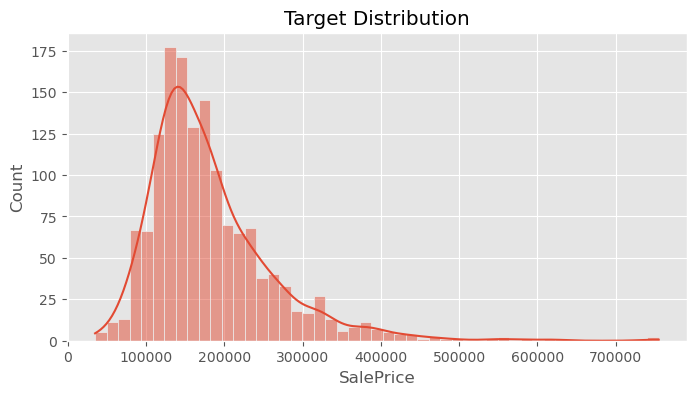

In [41]:
plt.figure(figsize=(8,4))
sns.histplot(y_train, kde=True)
plt.title("Target Distribution")
plt.show()

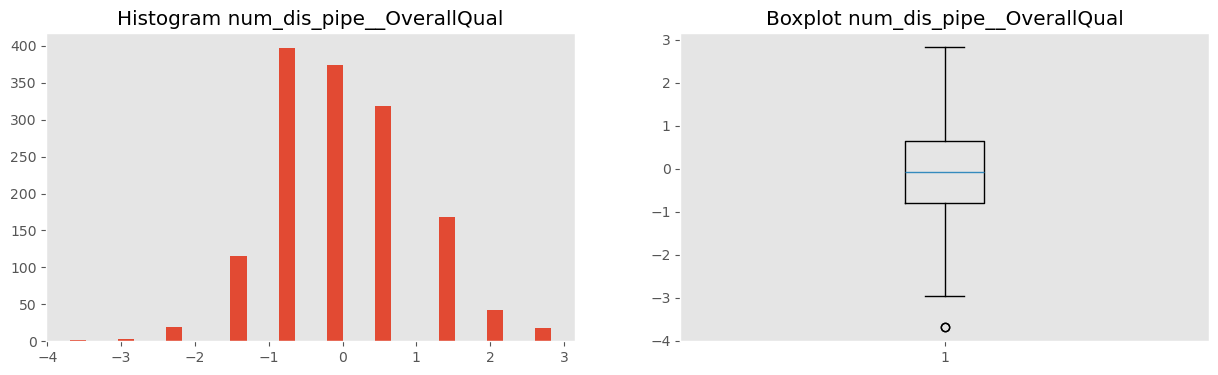

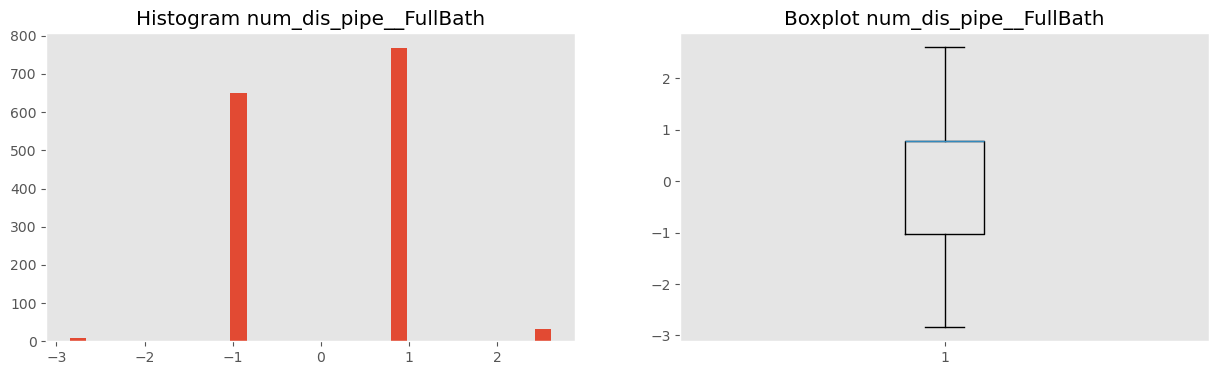

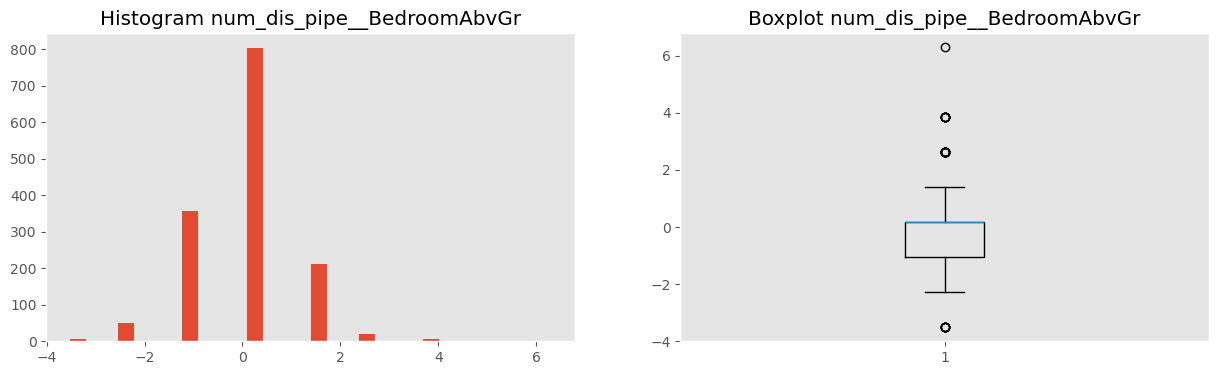

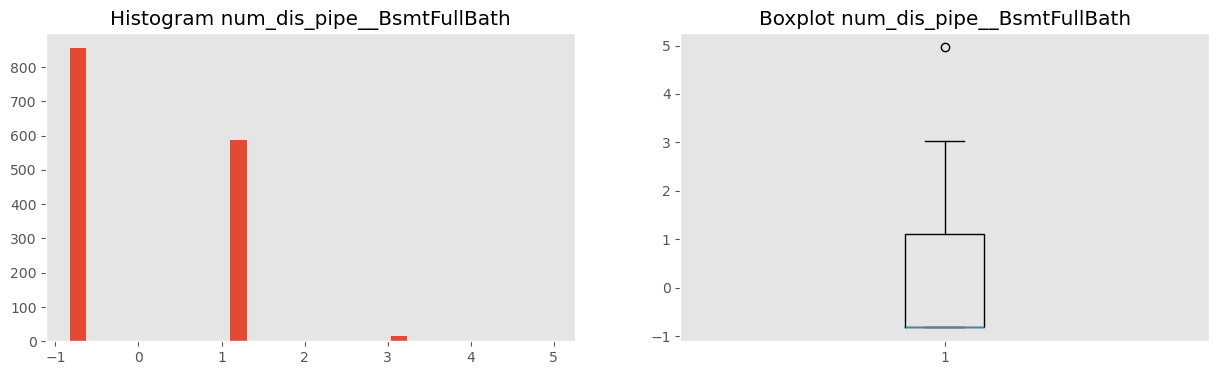

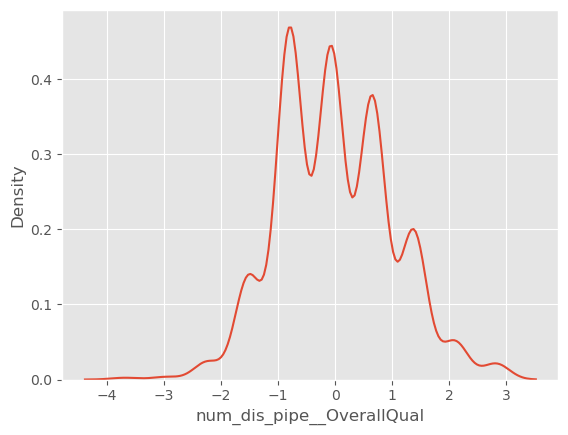

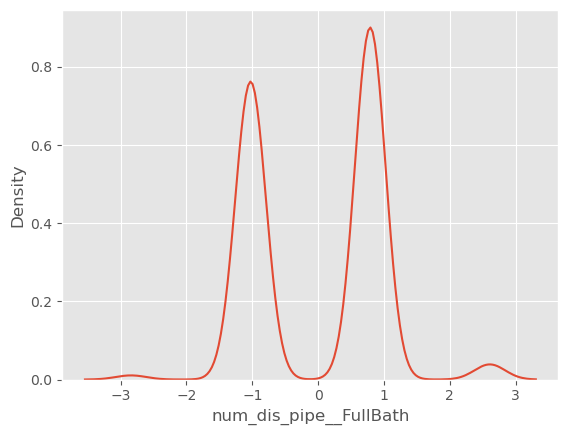

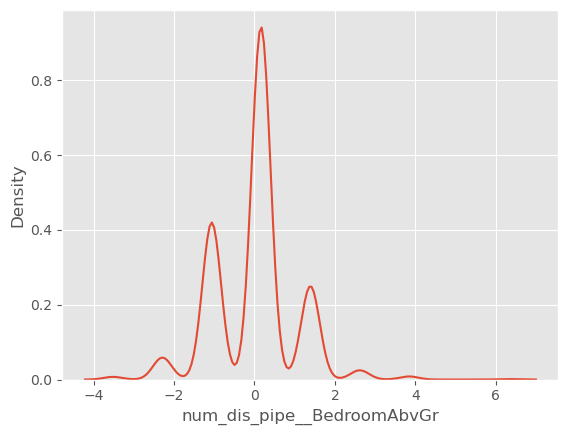

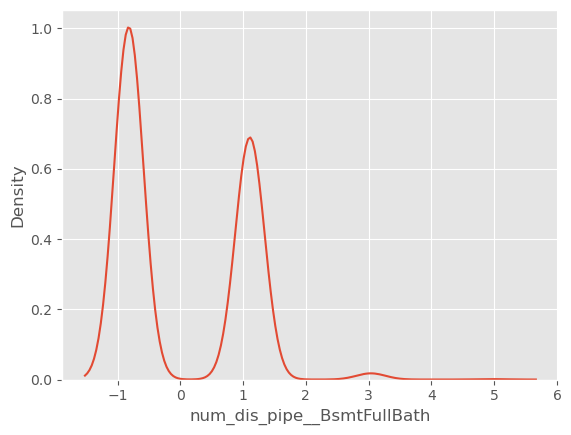

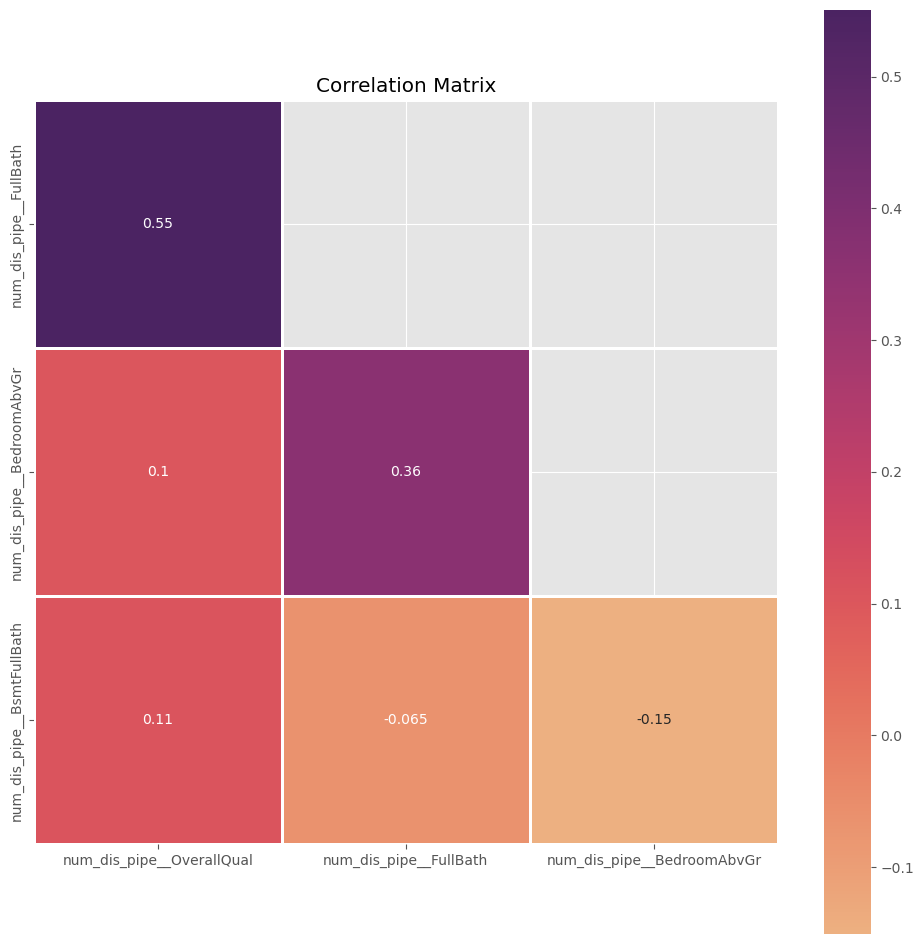

In [9]:
plot_numerical_data(X_train_trans.filter(regex='num_dis_pipe'), target=None)

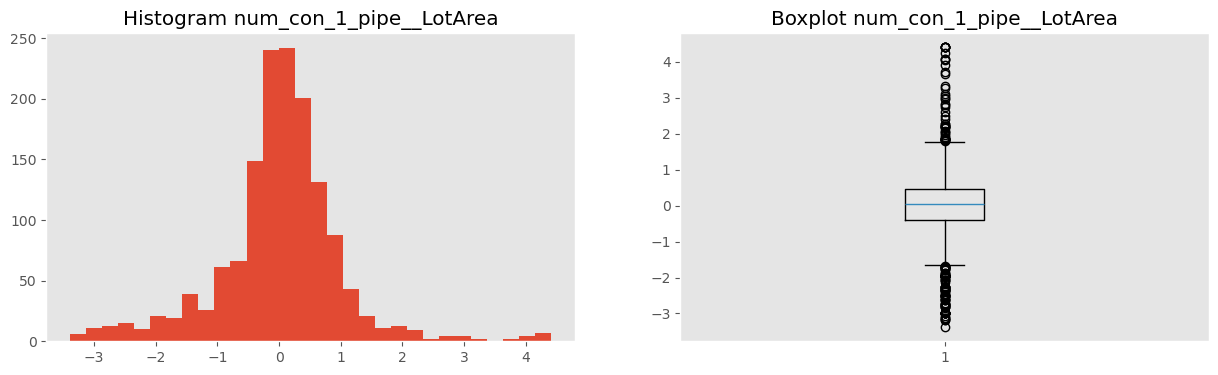

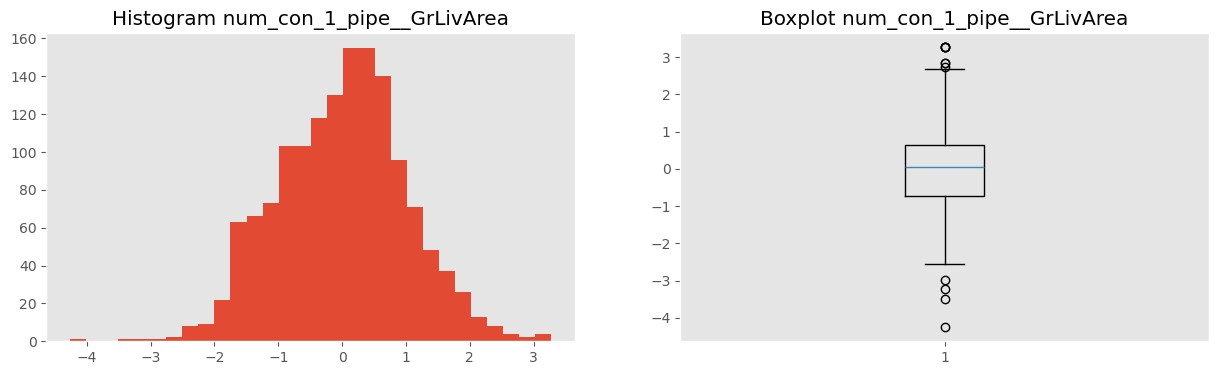

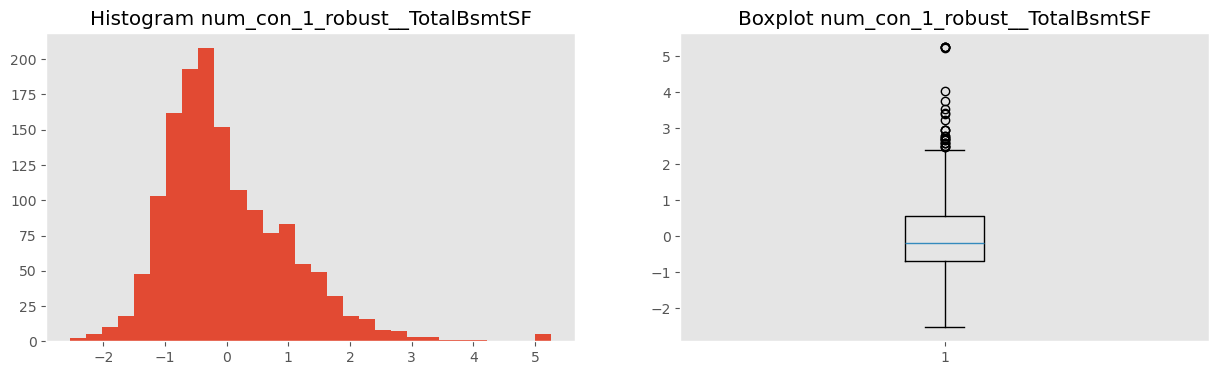

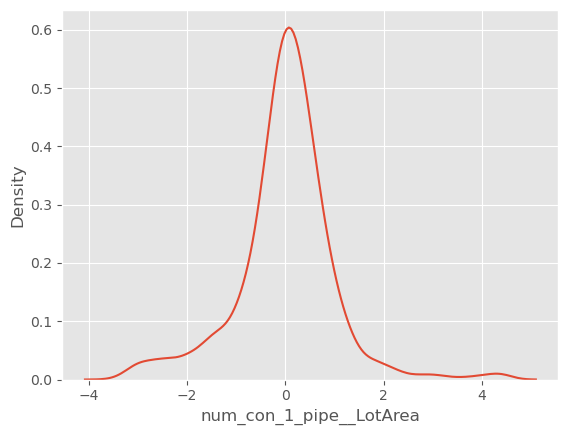

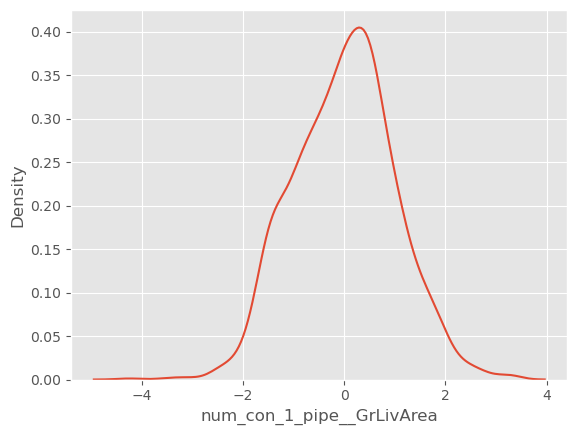

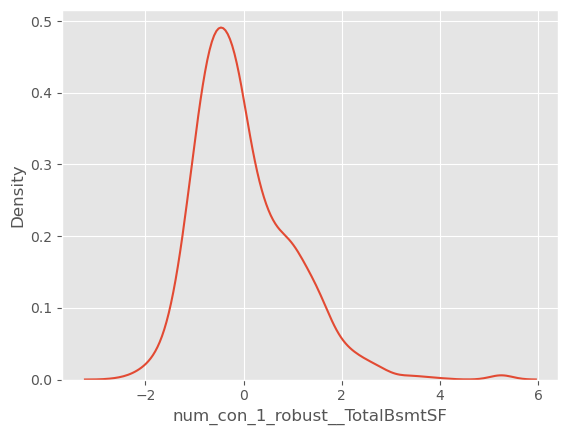

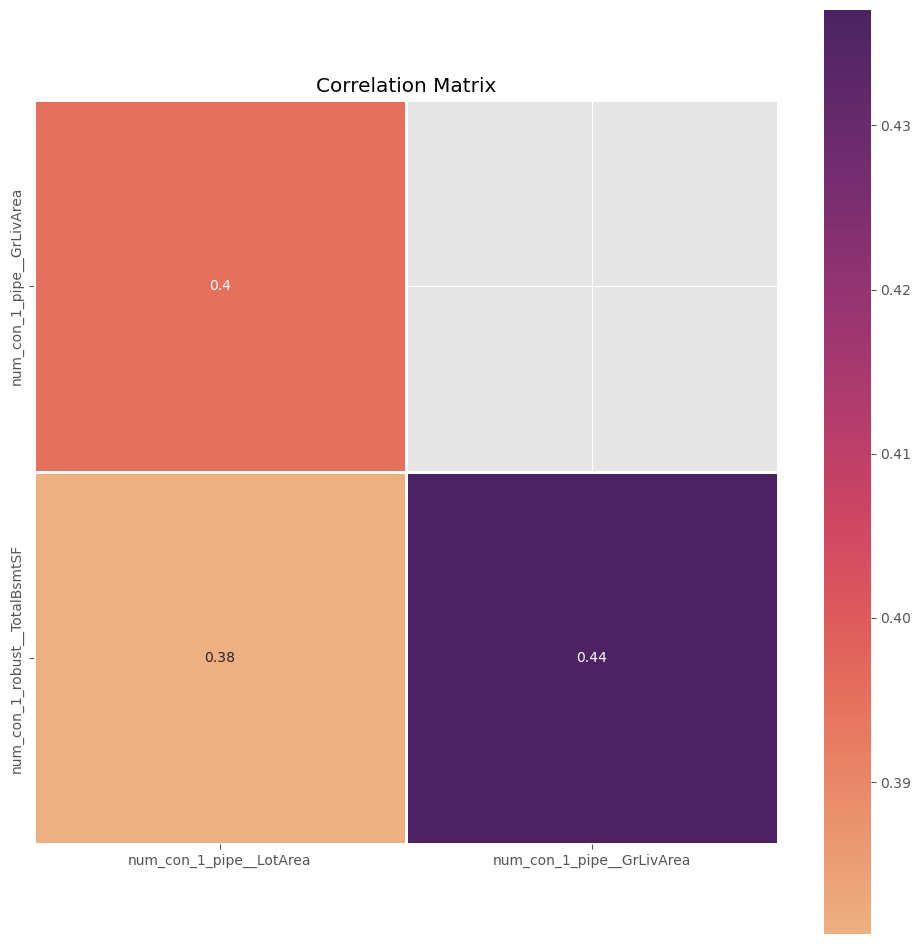

In [10]:
plot_numerical_data(X_train_trans.filter(regex='num_con_1_'), target=None)

In [11]:
X_train_trans.filter(regex='num_con_1_')

,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_1_robust__TotalBsmtSF
0,-0.171679,0.527354,-0.583479
1,0.083958,-0.388541,0.470989
2,0.409000,0.659460,-0.417257
3,0.073394,0.539754,-0.843200
4,0.910356,1.293543,0.167115
...,...,...,...
1455,-0.300237,0.413519,-0.331549
1456,0.740915,1.114094,1.198208
1457,-0.036658,1.485923,0.185296
1458,0.108497,-0.858847,-0.006898


In [12]:
np.corrcoef(X_train_trans['num_con_1_pipe__LotArea'], y_train)

array([[1.        , 0.39702323],
       [0.39702323, 1.        ]])

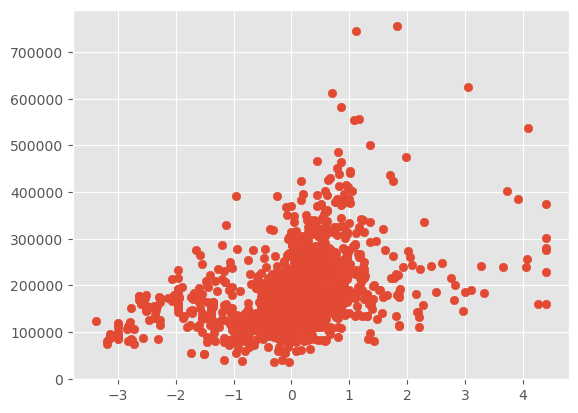

In [13]:
plt.scatter(
    x=X_train_trans['num_con_1_pipe__LotArea'],
    y=y_train
                );

In [14]:
np.corrcoef(X_train_trans['num_con_1_pipe__GrLivArea'], y_train)

array([[1.        , 0.69811727],
       [0.69811727, 1.        ]])

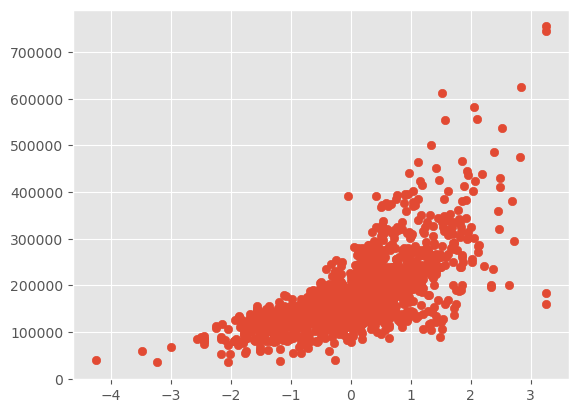

In [15]:
plt.scatter(
    x=X_train_trans['num_con_1_pipe__GrLivArea'],
    y=y_train
                );

In [16]:
np.corrcoef(X_train_trans['num_con_1_robust__TotalBsmtSF'], y_train)

array([[1.       , 0.6368839],
       [0.6368839, 1.       ]])

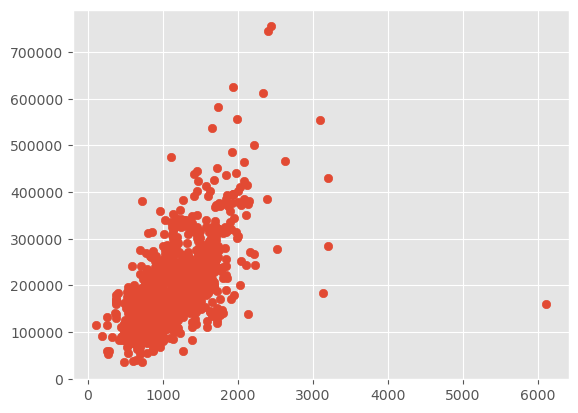

In [17]:
plt.scatter(
    x=X_train['TotalBsmtSF'],
    y=y_train
                );

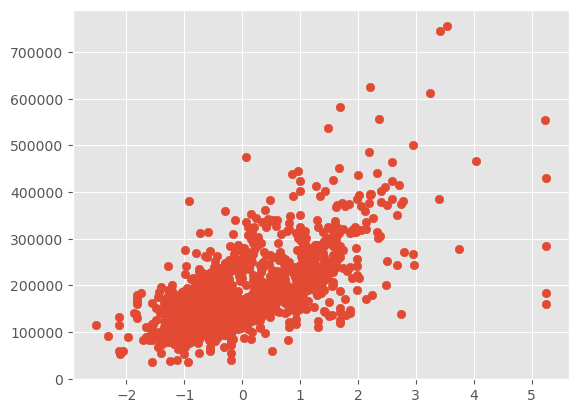

In [18]:
plt.scatter(
    x=X_train_trans['num_con_1_robust__TotalBsmtSF'],
    y=y_train
                );

In [ ]:
# for col in X_train_trans.filter(like='categorical').columns:
#     Bar_plot(X_train_trans[col].value_counts(), title=col)

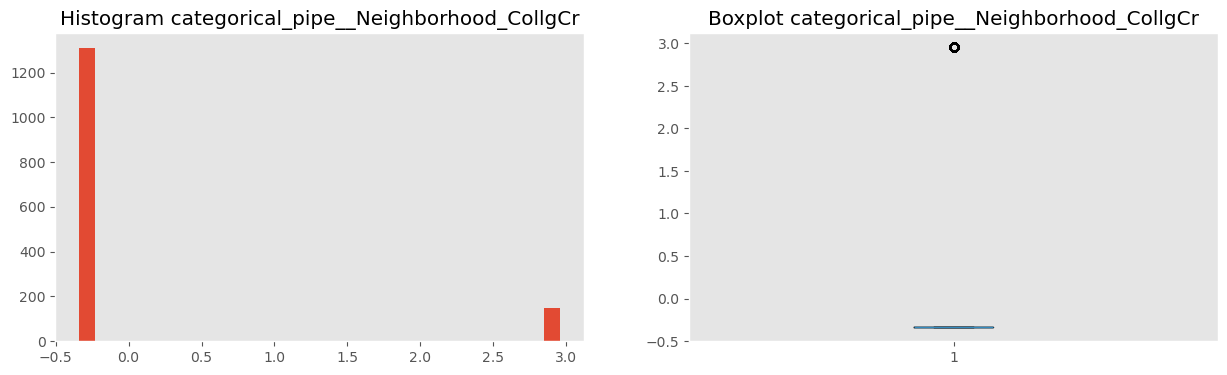

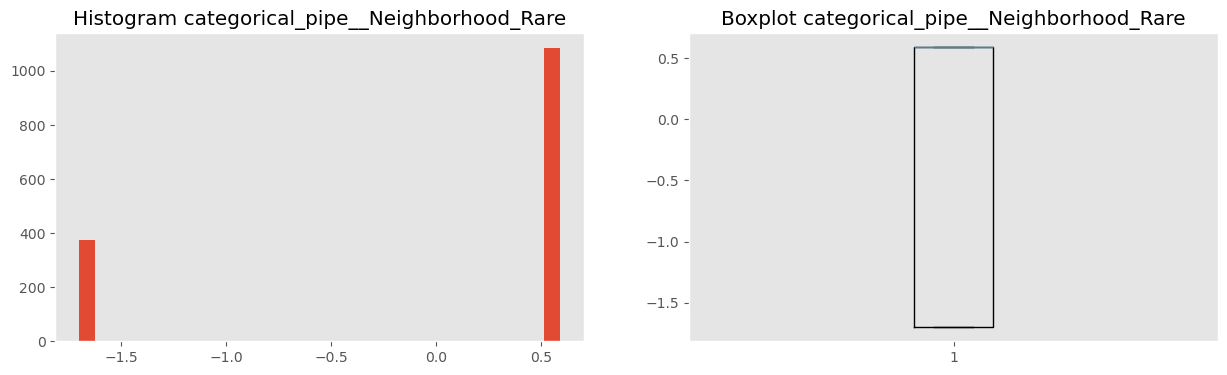

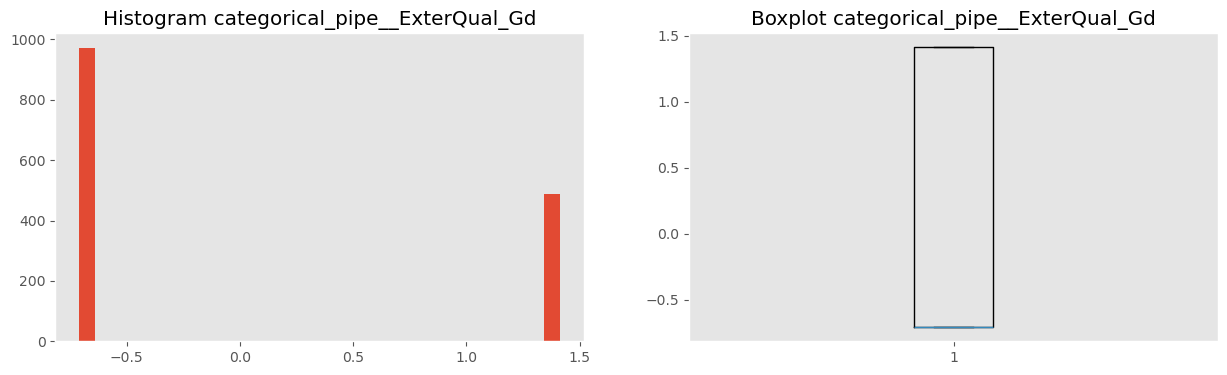

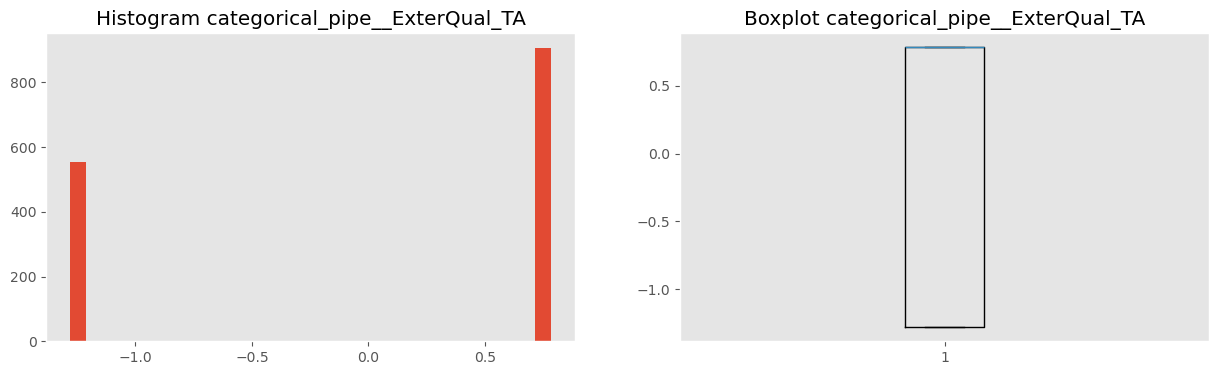

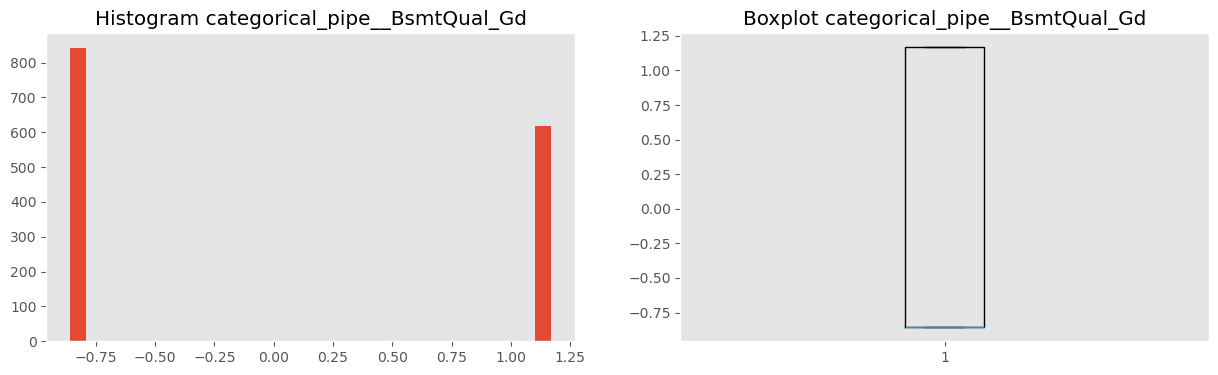

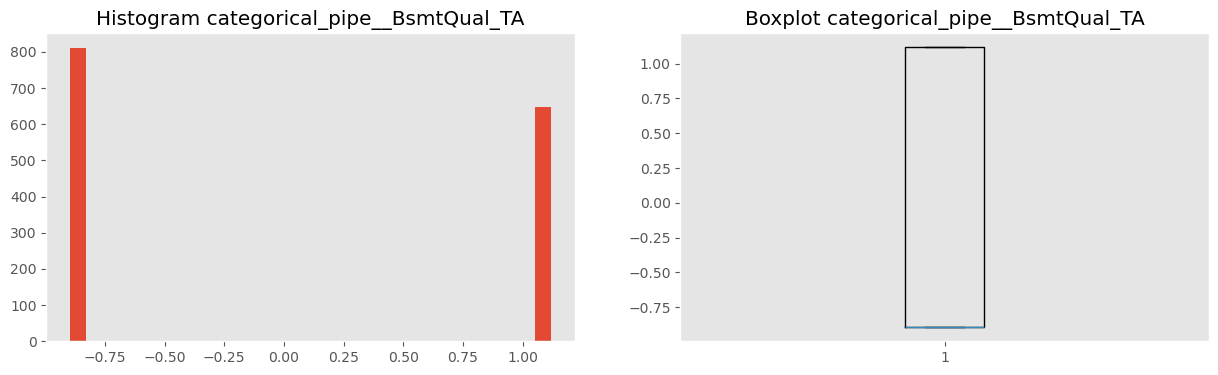

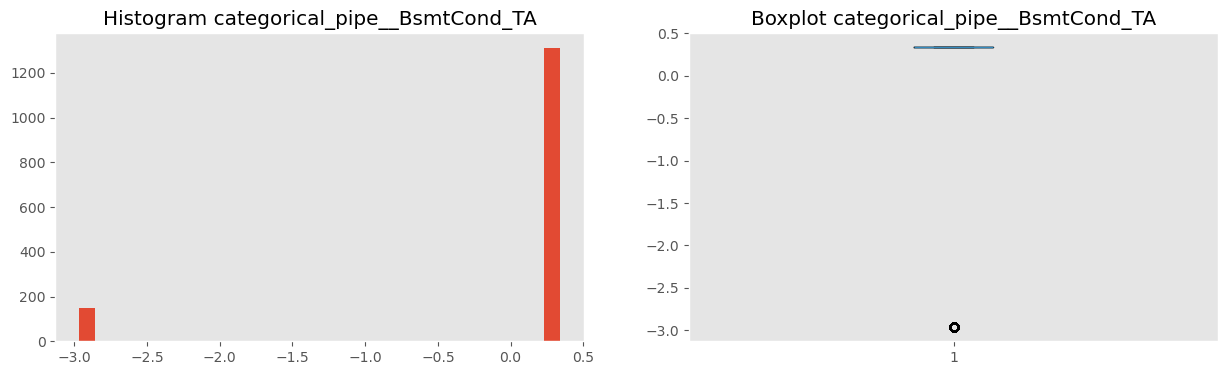

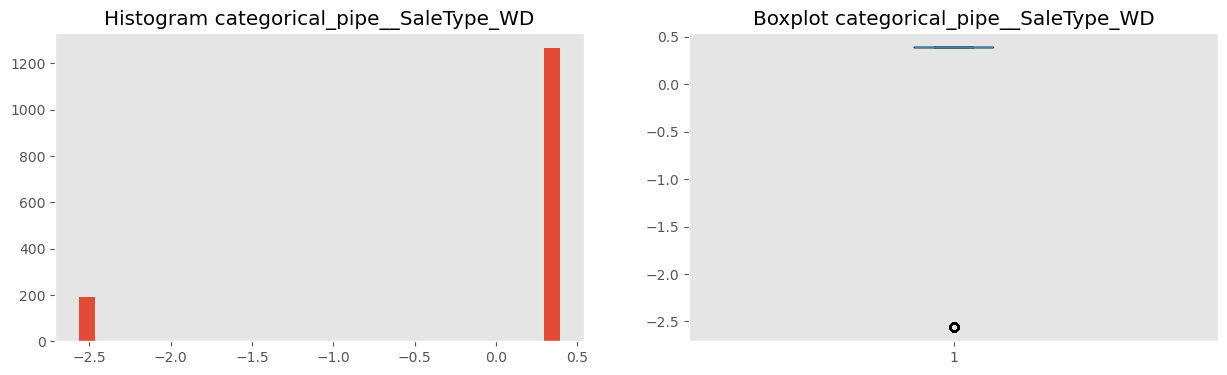

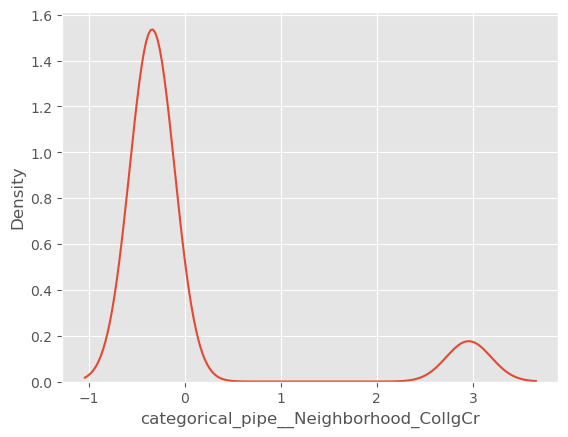

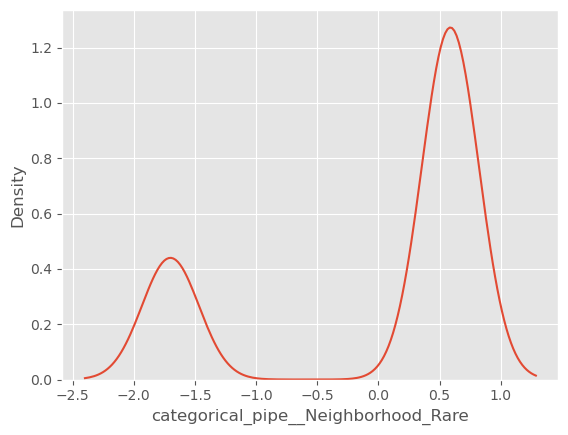

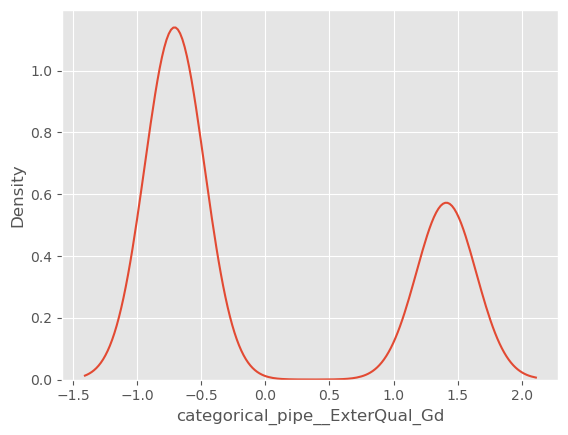

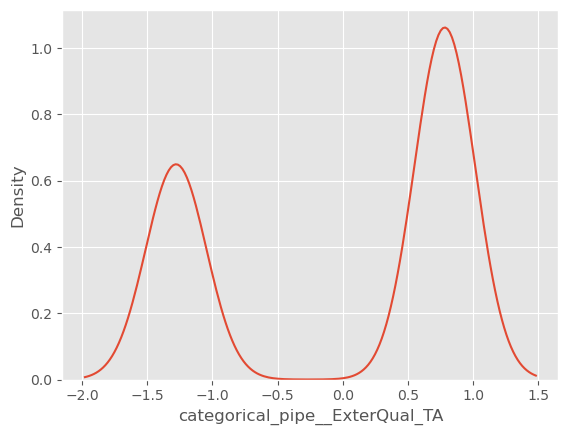

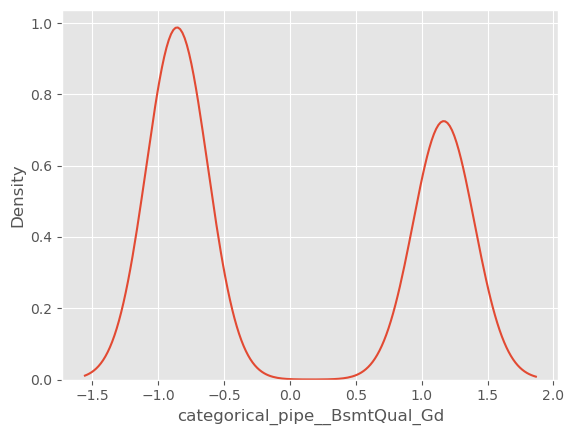

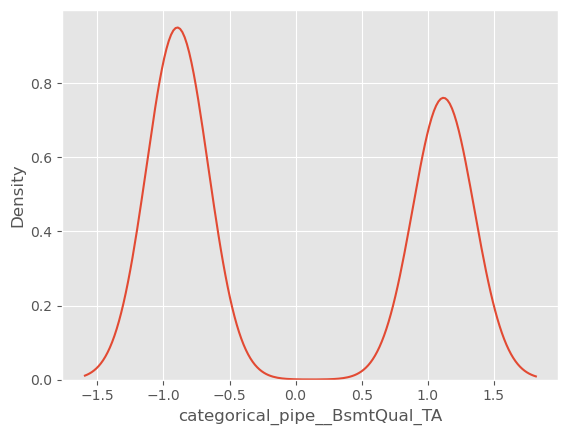

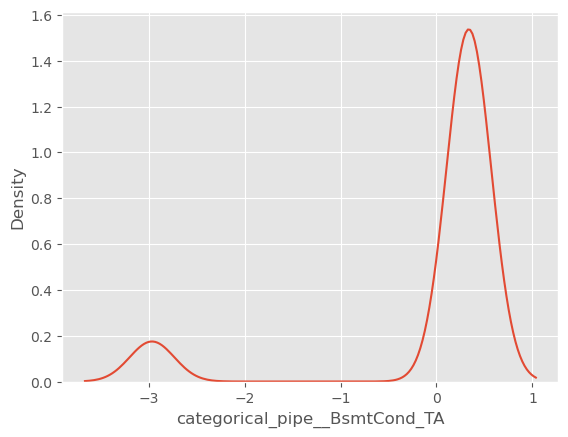

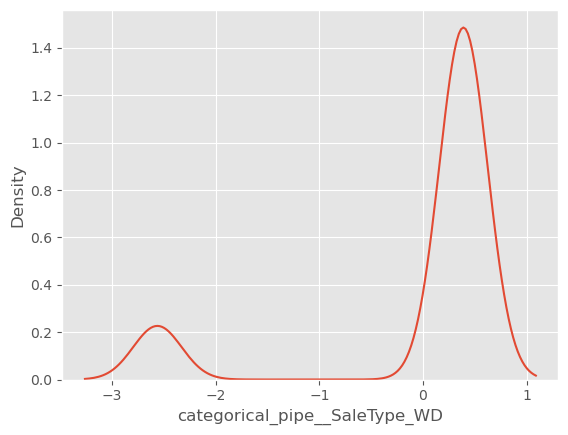

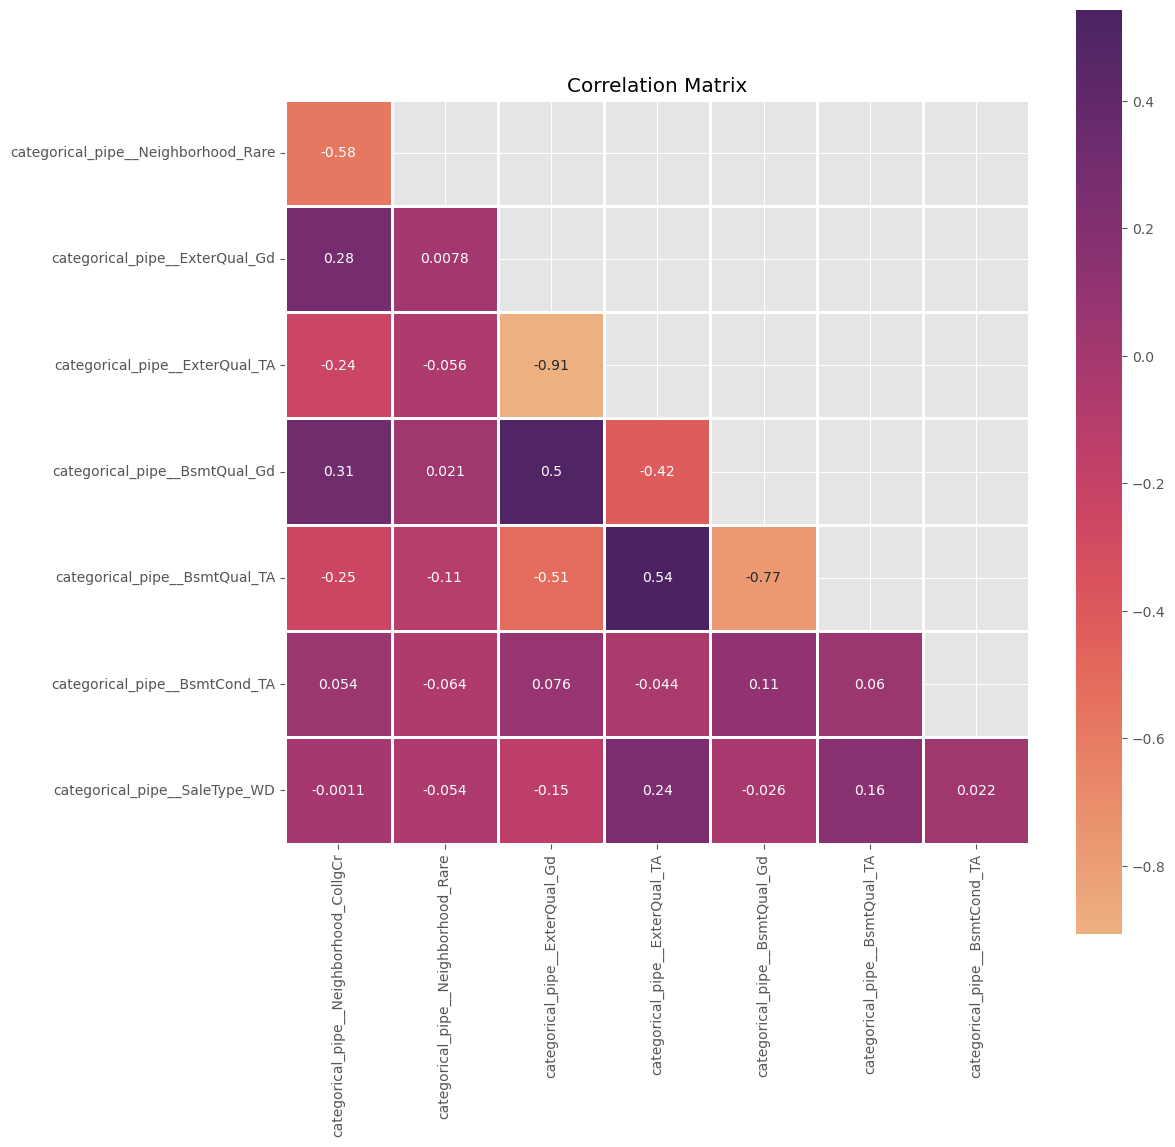

In [19]:
plot_numerical_data(X_train_trans.filter(regex='categorical'), target=None)

# Univariate Feat Selection

## Orquestrador

In [20]:
X_train_trans.filter(like='num')

,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,num_dis_pipe__BedroomAbvGr,num_dis_pipe__BsmtFullBath,num_con_1_robust__TotalBsmtSF
0,-0.171679,0.527354,0.751603,1.104594,-0.943203,0.832668,0.267021,0.651479,0.789741,0.163779,1.107810,-0.583479
1,0.083958,-0.388541,0.751603,-0.869042,1.285977,-1.064879,0.267021,-0.071836,0.789741,0.163779,-0.819964,0.470989
2,0.409000,0.659460,0.751603,1.104594,-0.943203,0.516410,0.267021,0.651479,0.789741,0.163779,1.107810,-0.417257
3,0.073394,0.539754,0.443880,1.104594,-0.943203,0.516410,0.267021,0.651479,-1.026041,0.163779,1.107810,-0.843200
4,0.910356,1.293543,0.751603,1.351299,1.007330,1.148926,0.792425,1.374795,0.789741,1.390023,1.107810,0.167115
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,-0.300237,0.413519,-1.402458,1.104594,-0.943203,0.516410,0.267021,-0.071836,0.789741,0.163779,-0.819964,-0.331549
1456,0.740915,1.114094,0.751603,-0.869042,1.285977,-1.064879,0.267021,-0.071836,0.789741,0.163779,1.107810,1.198208
1457,-0.036658,1.485923,0.443880,1.351299,-0.943203,0.832668,-0.258384,0.651479,0.789741,1.390023,-0.819964,0.185296
1458,0.108497,-0.858847,-0.171566,-0.869042,1.285977,-1.064879,-0.258384,-0.795151,-1.026041,-1.062465,1.107810,-0.006898


In [21]:
feature_selection = FeatureSelectionOrchestrator()

## Constant Features

In [22]:
constant_features = feature_selection.apply(
        "DropConstantFeatures", 
        X_train_trans, 
        y_train,
        threshold=0.90)

constant_features

[]

## Duplicate Features

In [23]:
duplicate_features = feature_selection.apply(
        "DropDuplicateFeatures", 
        X_train_trans,        
        y_train
        )

duplicate_features

set()

In [ ]:
# QuiSquare = feature_selection.apply(
#         "QuiSquare", 
#         X_train_trans.filter(like='categorical'), 
#         y_train)

# [i
#     for i in QuiSquare.loc[QuiSquare < 0.05].index
# ]

# # feature selection based on QuiSquare test
# [i
#     for i in QuiSquare.loc[QuiSquare > 0.05].index
# ]

## Anova

In [24]:
Anova = feature_selection.apply(
        "Anova",
        X_train_trans.filter(like='num'),
        y_train.values)

In [25]:
Anova.loc[Anova > 0.05]

Series([], Name: Anova, dtype: float64)

In [26]:
Anova.loc[Anova < 0.05]

num_dis_pipe__OverallQual        1.344399e-114
num_con_1_pipe__GrLivArea         1.799364e-59
num_con_1_robust__TotalBsmtSF     1.812656e-41
num_dis_pipe__FullBath            5.306331e-40
num_con_2_pipe__OpenPorchSF       1.985910e-11
num_con_2_pipe__GarageArea        7.588050e-09
num_con_1_pipe__LotArea           7.185116e-06
num_con_2_pipe__BsmtFinSF1        4.023059e-05
num_con_2_pipe__WoodDeckSF        9.908564e-05
num_dis_pipe__BedroomAbvGr        2.144007e-03
num_con_2_pipe__2ndFlrSF          1.860987e-02
num_dis_pipe__BsmtFullBath        4.326529e-02
Name: Anova, dtype: float64

## Mutual Info

In [27]:
mi = feature_selection.apply(
        "MutualInformationReg", 
        X_train_trans, 
        y_train)

In [28]:
mi

num_dis_pipe__OverallQual                 0.555940
num_con_1_pipe__GrLivArea                 0.491896
num_con_1_robust__TotalBsmtSF             0.365172
categorical_pipe__ExterQual_TA            0.270395
num_con_2_pipe__GarageArea                0.264164
num_dis_pipe__FullBath                    0.250594
categorical_pipe__ExterQual_Gd            0.213821
num_con_1_pipe__LotArea                   0.184074
categorical_pipe__BsmtQual_TA             0.164049
categorical_pipe__BsmtQual_Gd             0.152855
num_con_2_pipe__OpenPorchSF               0.144698
num_con_2_pipe__BsmtFinSF1                0.100808
num_con_2_pipe__2ndFlrSF                  0.093448
num_con_2_pipe__WoodDeckSF                0.075958
num_dis_pipe__BedroomAbvGr                0.075127
categorical_pipe__Neighborhood_Rare       0.060437
categorical_pipe__SaleType_WD             0.042004
categorical_pipe__Neighborhood_CollgCr    0.022980
num_dis_pipe__BsmtFullBath                0.014556
categorical_pipe__BsmtCond_TA  

## Correlation

In [29]:
   
corr = feature_selection.apply(
        "PearsonCorrelation", 
        X_train_trans.filter(like='num'), 
        y_train)

In [30]:
corr

,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,num_dis_pipe__BedroomAbvGr,num_dis_pipe__BsmtFullBath,num_con_1_robust__TotalBsmtSF
num_con_1_pipe__LotArea,1.000000,0.395227,0.104491,-0.005269,0.131962,0.142994,0.213407,0.185997,0.184003,0.277012,0.140177,0.380752
num_con_1_pipe__GrLivArea,0.395227,1.000000,-0.010219,0.560453,0.218804,0.392884,0.313450,0.613372,0.654180,0.540688,0.018801,0.437032
num_con_2_pipe__BsmtFinSF1,0.104491,-0.010219,1.000000,-0.206972,0.089192,0.013142,0.116020,0.057804,-0.082270,-0.094150,0.594347,0.228842
num_con_2_pipe__2ndFlrSF,-0.005269,0.560453,-0.206972,1.000000,0.038247,0.168917,0.047389,0.196317,0.319357,0.441121,-0.212888,-0.352676
num_con_2_pipe__WoodDeckSF,0.131962,0.218804,0.089192,0.038247,1.000000,0.131081,0.164214,0.279158,0.228179,0.016865,0.165182,0.204058
num_con_2_pipe__OpenPorchSF,0.142994,0.392884,0.013142,0.168917,0.131081,1.000000,0.191134,0.442274,0.377641,0.084890,0.077678,0.270339
num_con_2_pipe__GarageArea,0.213407,0.313450,0.116020,0.047389,0.164214,0.191134,1.000000,0.396872,0.241302,0.023784,0.088524,0.270098
num_dis_pipe__OverallQual,0.185997,0.613372,0.057804,0.196317,0.279158,0.442274,0.396872,1.000000,0.550600,0.101676,0.111098,0.510700
num_dis_pipe__FullBath,0.184003,0.654180,-0.082270,0.319357,0.228179,0.377641,0.241302,0.550600,1.000000,0.363252,-0.064512,0.370545
num_dis_pipe__BedroomAbvGr,0.277012,0.540688,-0.094150,0.441121,0.016865,0.084890,0.023784,0.101676,0.363252,1.000000,-0.150673,0.053994


## Smart Corr

In [31]:
smart_corr = feature_selection.apply(
        "SmartCorrelatedSelection",
        X_train_trans,
        y_train)

smart_corr

{'corr_feature': ['categorical_pipe__ExterQual_Gd',
  'categorical_pipe__ExterQual_TA'],
 'corr_2_drop': ['categorical_pipe__ExterQual_TA']}

## MRMR

In [32]:
mrmr = feature_selection.apply(
        "MRMR",        
        X_train_trans,
        y_train,
        method="MIQ"
        )

In [33]:
X_train_trans.shape

(1460, 20)

In [34]:
len(mrmr['features_to_drop'])

16

In [35]:
mrmr['features_to_drop'] 

['num_con_1_pipe__GrLivArea',
 'num_con_2_pipe__BsmtFinSF1',
 'num_con_2_pipe__2ndFlrSF',
 'num_con_2_pipe__WoodDeckSF',
 'num_con_2_pipe__OpenPorchSF',
 'num_con_2_pipe__GarageArea',
 'num_dis_pipe__OverallQual',
 'num_dis_pipe__FullBath',
 'num_dis_pipe__BedroomAbvGr',
 'num_dis_pipe__BsmtFullBath',
 'categorical_pipe__Neighborhood_CollgCr',
 'categorical_pipe__Neighborhood_Rare',
 'categorical_pipe__ExterQual_TA',
 'categorical_pipe__BsmtQual_Gd',
 'categorical_pipe__BsmtQual_TA',
 'num_con_1_robust__TotalBsmtSF']

In [36]:
mrmr['relevance']

array([0.14305406, 0.38895126, 0.46593729, 0.98997606, 0.83787869,
       0.84456856, 1.5990097 , 1.13306429, 2.24448009, 0.90466969,
       1.23761258, 2.48333256, 1.71037548, 2.17937889, 2.19000287,
       1.83402822, 1.86992566, 2.38904551, 2.61868846, 0.22276079])